In [ ]:
!pwd

In [ ]:
import subprocess
import time
from pathlib import Path


loops_dir = Path("build/neon/standalone/bin/")

loops = []
for file in loops_dir.iterdir():
    if file.is_file():
        loops.append(int(file.stem.split("_")[1]))
loops.sort()
print(f'{len(loops)} loops found.')

REPETITIONS = 1_000_000

selected_loops = []
for id in loops:
    cmd = [f"build/neon/bin/simd_loops", "-k", str(id), "-n", str(REPETITIONS)]
    
    start = time.time()
    output = subprocess.run(cmd, capture_output=True, text=True)
    end = time.time()
    
    if output.returncode != 0:
        print(f"Loop {id} execution failed with error:")
        print(output.stdout)
        continue
        # raise RuntimeError(f"Loop {loop} execution failed.")
    else:
        output = output.stdout.strip()
        output = output.splitlines()
        loop_name = output[0].split(" - ")[1]
        loop_purpose = output[1].split(": ")[1]
        assert output[-1] == " - Checksum correct.", f"Loop {id} failed checksum verification."

    id = (id, loop_name, loop_purpose, end - start)
    print(id)
    selected_loops.append(id)

In [3]:
TARGET_DURATION = 10 # seconds

In [ ]:
loops = []
for (id, name, purpose, duration) in selected_loops:
    single_duration = duration / REPETITIONS
    iterations = int(TARGET_DURATION / single_duration)
    print(f"Loop {id} - {iterations} iterations to reach {TARGET_DURATION} seconds")
    loops.append(
        {
            "id": id,
            "name": name,
            "purpose": purpose,
            "iterations": iterations
            }
            )

import json
with open(f'loops.{TARGET_DURATION}s.json', "w") as f:
    json.dump(loops, f, indent=1)
!cat loops.{TARGET_DURATION}s.json

In [7]:
import json

loops = json.load(open(f'loops.{TARGET_DURATION}s.json'))

In [8]:
modes = ["neon", "sve", "sve2"]
lines = []
for mode in modes:
    lines.append(f'#!/bin/bash')
    lines.append(f'\n')

    for loop in loops:
        id = loop["id"]
        name = loop["name"]
        iterations = loop["iterations"]
        purpose = loop["purpose"]
        
        lines.append(f'echo id={id}')
        lines.append(f'echo mode={mode}')
        lines.append(f'echo start=$(date +%s.%N)')
        lines.append(f'./build/{mode}/bin/simd_loops -k {id} -n {iterations} > /dev/null 2>&1')
        lines.append(f'echo code=$?')
        lines.append(f'echo end=$(date +%s.%N)')
        lines.append(f'echo')
        lines.append(f'\n')

with open(f'run.sh', "w") as f:            
    f.writelines(line + "\n" for line in lines)

!cat run.sh

#!/bin/bash


echo id=1
echo mode=neon
echo start=$(date +%s.%N)
./build/neon/bin/simd_loops -k 1 -n 17388015 > /dev/null 2>&1
echo code=$?
echo end=$(date +%s.%N)
echo


echo id=2
echo mode=neon
echo start=$(date +%s.%N)
./build/neon/bin/simd_loops -k 2 -n 22637834 > /dev/null 2>&1
echo code=$?
echo end=$(date +%s.%N)
echo


echo id=3
echo mode=neon
echo start=$(date +%s.%N)
./build/neon/bin/simd_loops -k 3 -n 18300985 > /dev/null 2>&1
echo code=$?
echo end=$(date +%s.%N)
echo


echo id=4
echo mode=neon
echo start=$(date +%s.%N)
./build/neon/bin/simd_loops -k 4 -n 17755418 > /dev/null 2>&1
echo code=$?
echo end=$(date +%s.%N)
echo


echo id=5
echo mode=neon
echo start=$(date +%s.%N)
./build/neon/bin/simd_loops -k 5 -n 7889564 > /dev/null 2>&1
echo code=$?
echo end=$(date +%s.%N)
echo


echo id=6
echo mode=neon
echo start=$(date +%s.%N)
./build/neon/bin/simd_loops -k 6 -n 22328548 > /dev/null 2>&1
echo code=$?
echo end=$(date +%s.%N)
echo


echo id=8
echo mode=neon
echo start=$(date +%

In [9]:
import pandas as pd


def machine_name(machine):
    if machine == "apple":
        return "Apple M4 Pro"
    elif machine == "google":
        return "Google Axion"
    else:
        return machine
    
def mode_name(mode):
    if mode == "neon":
        return "NEON"
    elif mode == "sve":
        return "SVE"
    elif mode == "sve2":
        return "SVE2"
    else:
        return mode
    
def loops_name(id):
    for loop in loops:
        if loop["id"] == id:
            return loop["name"]
    return None

machines = [
    "apple", 
    "google"
]
    
modes = ["neon", "sve", "sve2"]

data = []
for machine in machines:    
    print(f"[machine] {machine}")
    with open(f"profiles/{machine}.txt", "r") as f:
            lines = f.readlines()
            lines = [line.strip() for line in lines if line.strip()]
    
    i = 0
    while i < len(lines):
        assert lines[i].startswith("id="), f"Expected line starting with 'id=' but got: {lines[i]}"
        id = int(lines[i].split("=")[1])
        i += 1
        
        assert lines[i].startswith("mode="), f"Expected line starting with 'mode=' but got: {lines[i]}"
        mode = lines[i].split("=")[1]
        i += 1
        
        assert lines[i].startswith("start="), f"Expected line starting with 'start=' but got: {lines[i]}"
        start = float(lines[i].split("=")[1])
        i += 1

        assert lines[i].startswith("code="), f"Expected line starting with 'code=' but got: {lines[i]}"
        code = int(lines[i].split("=")[1])
        i += 1

        assert lines[i].startswith("end="), f"Expected line starting with 'end=' but got: {lines[i]}"
        end = float(lines[i].split("=")[1])
        i += 1
        
        duration = end - start if code == 0 else None

        data.append((machine, mode, id, duration))

df = pd.DataFrame(data, columns=["machine", "mode", "id", "duration"])
df

[machine] apple
[machine] google


,machine,mode,id,duration
0,apple,neon,1,9.127112
1,apple,neon,2,9.681514
2,apple,neon,3,9.851107
3,apple,neon,4,9.954085
4,apple,neon,5,9.740594
...,...,...,...,...
355,google,sve2,221,16.329593
356,google,sve2,222,8.557702
357,google,sve2,223,27.564917
358,google,sve2,231,5.245740


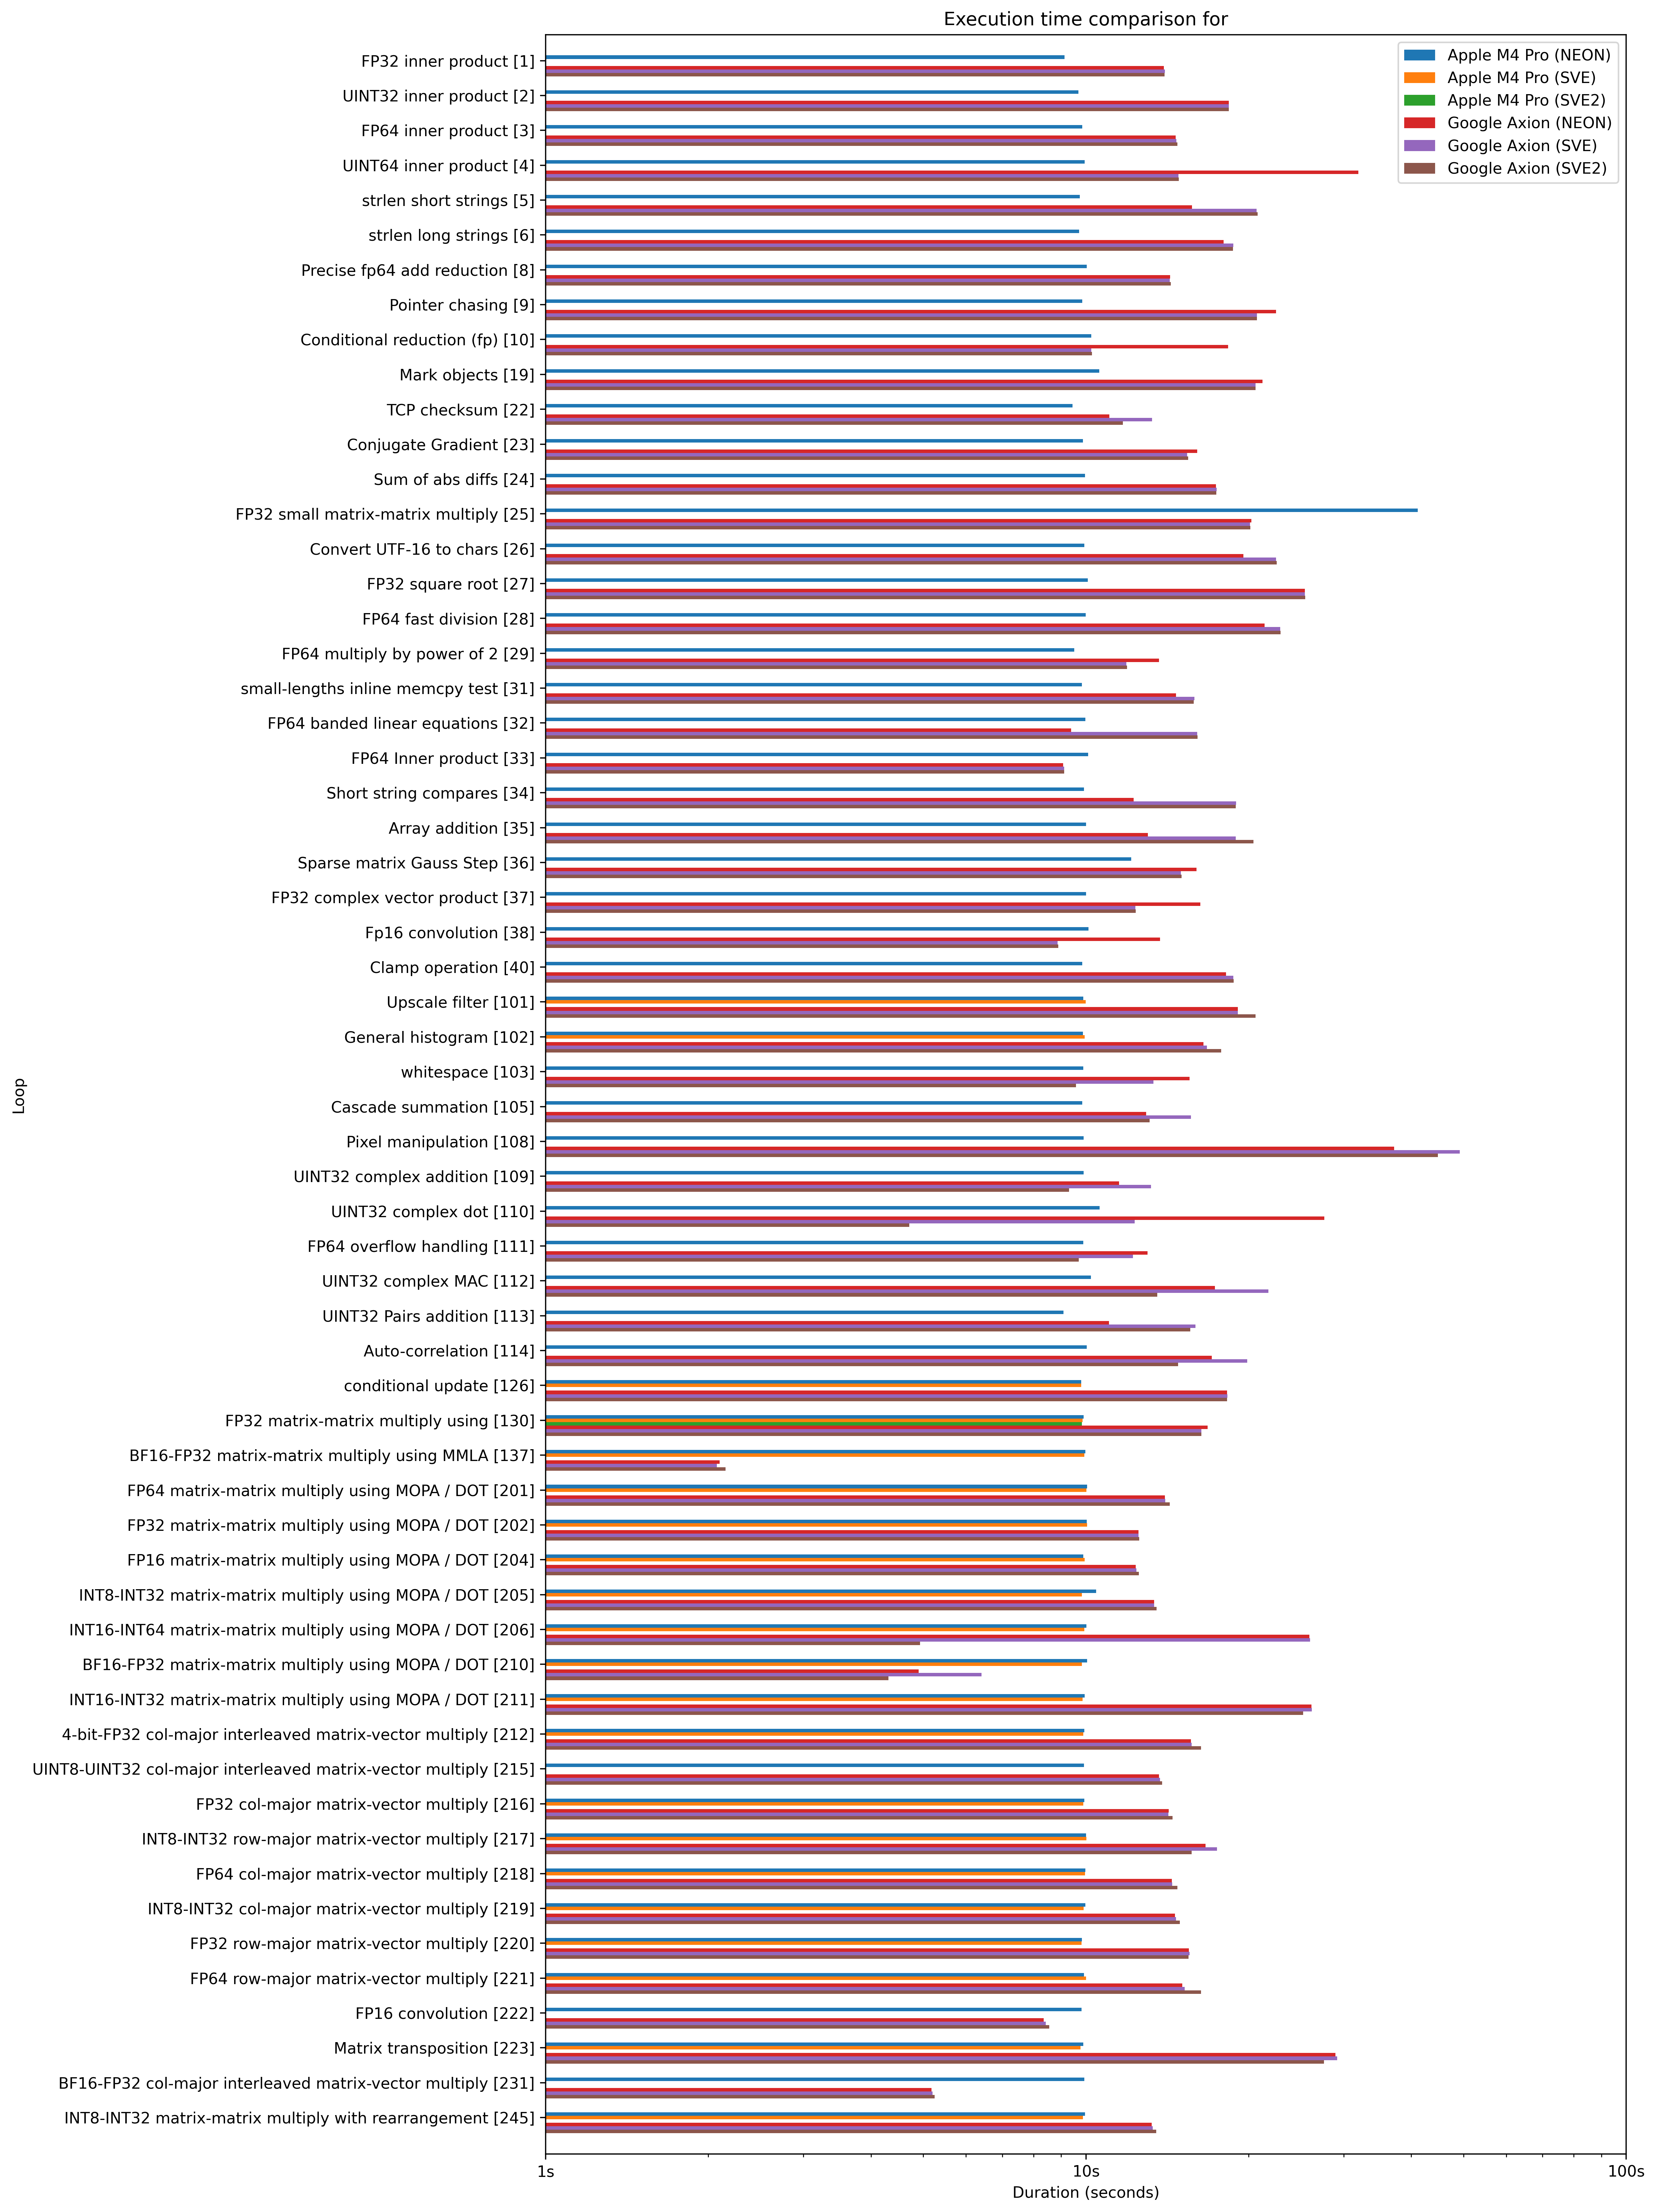

In [10]:
bars = []
for machine in machines:
    for mode in modes:
        subset = df[(df["machine"] == machine) & (df["mode"] == mode)]
        bars.append(
            {
                "machine": machine,
                "mode": mode,
                "ids": subset["id"].tolist(),
                "durations": subset["duration"].tolist()
            }
        )
        
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,20), dpi=320)
bar_width = 0.6 / len(bars)
for i, bar in enumerate(bars):
    x = np.arange(len(bar["ids"])) + i * bar_width
    plt.barh(x, bar["durations"], height=bar_width, label=f'{machine_name(bar["machine"])} ({mode_name(bar["mode"])})')
    
    
# make x log
plt.xscale("log")

plt.xlabel("Duration (seconds)")
plt.ylabel("Loop")

# revert y-axis to have the highest loop ID at the top
plt.gca().invert_yaxis()

# write the loop name on the y-axis
plt.yticks(np.arange(len(bars[0]["ids"])) + bar_width, [f'{loops_name(id)} [{id}]' for id in bars[0]["ids"]])

# write 0.01, 0.1, 1, 10 on the x-axis
plt.xticks([1, 10, 100], ["1s", "10s", "100s"])

plt.title("Execution time comparison for")
plt.legend(loc="upper right")

# y margin to 0.1
plt.margins(y=0.01)

plt.tight_layout()
# plt.savefig("loop_durations.png")
plt.show()